## Introduction
Chronic Kidney Disease (CKD) is a serious medical condition that affects the functioning of kidneys and can lead to severe health complications if not

detected early.  This project focuses on analyzing kidney disease patient data using Exploratory Data Analysis (EDA) and Machine Learning techniques

to identify important medical indicators associated with CKD prediction. The project helps in understanding patterns, relationships

and risk factors present in the dataset.

## Problem Statement
The main aim of this project is to build a predictive model that can accurately classify whether a patient is suffering from Chronic Kidney Disease

(CKD) or not based on various medical attributes such as blood pressure, blood glucose, serum creatinine, hemoglobin, and other health indicators.

## Objective
* To perform data preprocessing and handle missing values.
* To analyze numerical and categorical features using visualization techniques.
* To identify patterns, correlations, and outliers in the dataset.
* To apply feature engineering and multicollinearity checks using VIF.
* To build classification models for CKD prediction.
* To evaluate model performance using metrics such as accuracy, confusion matrix, ROC-AUC, and classification report.

## Dataset Description
The dataset contains medical records of patients with several clinical and laboratory measurements used for kidney disease diagnosis.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
print('Number of rows:' , df.shape[0])
print('Number of columns:' , df.shape[1])

Number of rows: 400
Number of columns: 26


**Inference:** The number of rows are 400 and number of columns are 26

In [4]:
df.size

10400

In [5]:
df.info

<bound method DataFrame.info of       id   age    bp     sg   al   su     rbc        pc         pcc  \
0      0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent   
1      1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent   
2      2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent   
3      3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present   
4      4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent   
..   ...   ...   ...    ...  ...  ...     ...       ...         ...   
395  395  55.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
396  396  42.0  70.0  1.025  0.0  0.0  normal    normal  notpresent   
397  397  12.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
398  398  17.0  60.0  1.025  0.0  0.0  normal    normal  notpresent   
399  399  58.0  80.0  1.025  0.0  0.0  normal    normal  notpresent   

             ba  ...  pcv    wc   rc  htn   dm  cad appet   pe  ane  \
0    notpresent  ...   44  7800  5.2  yes  y

In [6]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,400.0,199.500000,115.614301,0.000,99.75,199.50,299.25,399.000
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000


## Removing unwanted columns

In [8]:
df.drop('id' , axis = 1 , inplace = True)

**Inference:** Removed id because it is not a medical term and it is an unncecessary column in this data

### Checking duplicated values

In [9]:
df[df.duplicated()]

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification


**Inference:** There are no duplicate values

### Checking null values

In [10]:
df.isnull().sum()

age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

### Treating null values

Note: Treating null values with median because they are robust to outliers

In [11]:
df.dtypes

age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [12]:
df['age'] = df['age'].fillna(df['age'].median())

In [13]:
df['bp'] = df['bp'].fillna(df['bp'].median())

In [14]:
df['sg'] = df['sg'].fillna(df['sg'].median())

In [15]:
df['al'] = df['al'].fillna(df['al'].median())

In [16]:
df['su'] = df['su'].fillna(df['su'].median())

In [17]:
df['rbc'] = df['rbc'].fillna(df['rbc'].mode()[0])

In [18]:
df['pc'] = df['pc'].fillna(df['pc'].mode()[0])

In [19]:
df['pcc'] = df['pcc'].fillna(df['pcc'].mode()[0])

In [20]:
df['ba'] = df['ba'].fillna(df['ba'].mode()[0])

In [21]:
df['bgr'] = df['bgr'].fillna(df['bgr'].median())

In [22]:
df['bu'] = df['bu'].fillna(df['bu'].median())

In [23]:
df['sc'] = df['sc'].fillna(df['sc'].median())

In [24]:
df['sod'] = df['sod'].fillna(df['sod'].median())

In [25]:
df['pot']= df['pot'].fillna(df['pot'].median())

In [26]:
df['hemo'] = df['hemo'].fillna(df['hemo'].median())

In [27]:
df['pcv'] =df['pcv'].fillna(df['pcv'].mode()[0])

In [28]:
df['wc'] =df['wc'].fillna(df['wc'].mode()[0])

In [29]:
df['rc'] = df['rc'].fillna(df['rc'].mode()[0])

In [30]:
df['htn'] =df['htn'].fillna(df['htn'].mode()[0])

In [31]:
df['dm'] = df['dm'].fillna(df['dm'].mode()[0])

In [32]:
df['cad'] = df['cad'].fillna(df['cad'].mode()[0])

In [33]:
df['appet'] = df['appet'].fillna(df['appet'].mode()[0])

In [34]:
df['pe'] = df['appet'].fillna(df['appet'].mode()[0])

In [35]:
df['ane'] = df['ane'].fillna(df['ane'].mode()[0])

In [36]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

**Inference:** The null values are treated and the columns that are string are treated with mode

### Checking anomalies and treating them

In [37]:
for i in df.columns:
    print(i)
    print(df[i].unique())
    print('_________________')

age
[48.  7. 62. 51. 60. 68. 24. 52. 53. 50. 63. 40. 47. 61. 21. 42. 75. 69.
 55. 73. 70. 65. 76. 72. 82. 46. 45. 35. 54. 11. 59. 67. 15. 44. 26. 64.
 56.  5. 74. 38. 58. 71. 34. 17. 12. 43. 41. 57.  8. 39. 66. 81. 14. 27.
 83. 30.  4.  3.  6. 32. 80. 49. 90. 78. 19.  2. 33. 36. 37. 23. 25. 20.
 29. 28. 22. 79.]
_________________
bp
[ 80.  50.  70.  90. 100.  60. 110. 140. 180. 120.]
_________________
sg
[1.02  1.01  1.005 1.015 1.025]
_________________
al
[1. 4. 2. 3. 0. 5.]
_________________
su
[0. 3. 4. 1. 2. 5.]
_________________
rbc
['normal' 'abnormal']
_________________
pc
['normal' 'abnormal']
_________________
pcc
['notpresent' 'present']
_________________
ba
['notpresent' 'present']
_________________
bgr
[121. 423. 117. 106.  74. 100. 410. 138.  70. 490. 380. 208.  98. 157.
  76.  99. 114. 263. 173.  95. 108. 156. 264. 123.  93. 107. 159. 140.
 171. 270.  92. 137. 204.  79. 207. 124. 144.  91. 162. 246. 253. 141.
 182.  86. 150. 146. 425. 112. 250. 360. 163. 129. 133. 102. 15

In [38]:
df['dm'] = df['dm'].str.strip()

In [39]:
df['dm'].unique()

array(['yes', 'no'], dtype=object)

In [40]:
df['cad'] = df['cad'].replace({'\tno': 'no'})

In [41]:
df['cad'].unique()

array(['no', 'yes'], dtype=object)

In [42]:
df['classification'] = df['classification'].replace({'ckd\t': 'ckd'})

In [43]:
df['classification'].unique()

array(['ckd', 'notckd'], dtype=object)

In [44]:
df['classification'] = df['classification'].replace({'notckd':0, 'ckd':1})

In [45]:
yes_no = ['cad' , 'dm' , 'htn' , 'ane']

In [46]:
for i in yes_no:
    df[i] = df[i].replace({'no' : 0 ,'yes' :1})

In [47]:
normal_abnormal = ['pc' , 'rbc']

In [48]:
for i in normal_abnormal:
    df[i] = df[i].replace({'normal':1 , 'abnormal' : 0})

In [49]:
present_notpresent = ['pcc' , 'ba']

In [50]:
for i in present_notpresent:
    df[i] = df[i].replace({"present" : 1 , "notpresent" : 0})

In [51]:
good_poor = ['appet' , 'pe']

In [52]:
for i in good_poor:
    df[i] = df[i].replace({"good" : 1 , "poor" : 0})

In [53]:
col = ['pcv' , 'wc' , 'rc']

In [54]:
for i in col:
    df.replace('\t?', np.nan, inplace=True)

In [55]:
for i in col:
    df[i].fillna(df[i].mode()[0],inplace = True)

In [56]:
for i in col:
    df[i] = df[i].str.strip()

In [57]:
df['pcv'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', '41',
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '52', '14',
       '22', '18', '42', '17', '46', '23', '19', '25', '26', '15', '21',
       '43', '20', '47', '9', '49', '50', '53', '51', '54'], dtype=object)

In [58]:
df['wc'].unique()

array(['7800', '6000', '7500', '6700', '7300', '9800', '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9100', '7900', '6400', '8600',
       '18900', '21600', '4300', '8500', '11300', '7200', '7700', '14600',
       '6300', '7100', '11800', '9400', '5500', '5800', '13200', '12500',
       '5600', '7000', '11900', '10400', '10700', '12700', '6800', '6500',
       '13600', '10200', '9000', '14900', '8200', '15200', '5000',
       '16300', '12400', '10500', '4200', '4700', '10900', '8100', '9500',
       '2200', '12800', '11200', '19100', '12300', '16700', '2600',
       '26400', '8800', '7400', '4900', '8000', '12000', '15700', '4100',
       '5700', '11500', '5400', '10800', '9900', '5200', '5900', '9300',
       '9700', '5100', '6600'], dtype=object)

In [59]:
df['rc'].unique()

array(['5.2', '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4', '2.6',
       '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2', '4.5',
       '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3', '2.9',
       '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '5.4', '6.1', '6.2',
       '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7', '5.9', '6.5'],
      dtype=object)

**Inference:** There were anomalies in the columns and they were handled for columns like pcv , wc and rc has same type of anomalies so they were treated in the same way.
* First ,  the anomaly /t? was replaced with nan.
* Second ,  the null values were treated with mode as they are categoric columns.
* Finally , the anomaly which was having space was treated.

### Seperating numeric and categoric columns

In [60]:
num = df.select_dtypes(include = 'number').columns.tolist()
cat = df.select_dtypes(include = object).columns.tolist()

### Five point summary

In [61]:
df[cat].describe().T

,count,unique,top,freq
pcv,400,42,41,92
wc,400,89,9800,117
rc,400,48,5.2,149


**Inference:** The dataset indicates that while many patients exhibit normal clinical conditions, significant variability in numerical features and the presence of CKD cases highlight the importance of key medical indicators for accurate disease prediction.

### Summarize observations for categorical variables – no. of categories, % observations in each category

In [62]:
for i in cat:
    print(i)
    print(df[i].value_counts(normalize = True)*100)
    print('_______________________')

pcv
pcv
41    23.00
52     5.25
44     4.75
48     4.75
40     4.00
43     3.75
45     3.25
42     3.25
33     3.00
32     3.00
28     3.00
36     3.00
50     3.00
34     2.75
37     2.75
35     2.25
30     2.25
29     2.25
46     2.25
31     2.00
24     1.75
39     1.75
26     1.50
38     1.25
53     1.00
49     1.00
54     1.00
51     1.00
47     1.00
25     0.75
27     0.75
22     0.75
23     0.50
19     0.50
17     0.25
18     0.25
14     0.25
16     0.25
21     0.25
15     0.25
9      0.25
20     0.25
Name: proportion, dtype: float64
_______________________
wc
wc
9800    29.25
6700     2.50
9600     2.25
9200     2.25
7200     2.25
        ...  
9900     0.25
5900     0.25
5200     0.25
9700     0.25
5100     0.25
Name: proportion, Length: 89, dtype: float64
_______________________
rc
rc
5.2    37.25
4.5     4.00
4.9     3.50
4.7     2.75
4.8     2.50
3.9     2.50
4.6     2.25
3.4     2.25
5.0     2.00
6.1     2.00
5.9     2.00
5.5     2.00
3.7     2.00
3.8     1.75
5.4     1.75
5

**Inference:** In rbc the percentage of normal is more than that of abnormal , in pcc the percentage of notpresent seems to be more than that of present , in cad the percentage of  no is more than yes

### Outliers

In [63]:
iqr = df[num].quantile(0.75) - df[num].quantile(0.25)

In [64]:
lower_whis = df[num].quantile(0.25) - (1.5*iqr)

In [65]:
upper_whis = df[num].quantile(0.75) + (1.5*iqr)

In [66]:
outliers = df[((df[num] < lower_whis) | (df[num] > upper_whis)).any(axis = 1)]
outliers

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38,6000,5.2,0,0,0,1,1,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31,7500,5.2,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32,6700,3.9,1,0,0,0,0,1,1
6,68.0,70.0,1.010,0.0,0.0,1,1,0,0,100.0,...,36,9800,5.2,0,0,0,1,1,0,1
7,24.0,80.0,1.015,2.0,4.0,1,0,0,0,410.0,...,44,6900,5,0,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,48.0,100.0,1.020,0.0,0.0,1,1,0,0,103.0,...,19,7200,2.6,1,0,1,0,0,0,1
246,48.0,110.0,1.015,3.0,0.0,0,1,1,0,106.0,...,26,5000,2.5,1,0,1,1,1,1,1
247,54.0,90.0,1.025,1.0,0.0,1,0,0,0,150.0,...,41,9800,5.2,0,0,0,0,0,1,1
248,59.0,70.0,1.010,1.0,3.0,0,0,0,0,424.0,...,37,10200,4.1,1,1,1,1,1,0,1


**Inference:** Almost 60% of the data has outliers but we will keep it as it is so we can treat them in further analysis

## Visualisation

In [67]:
plt.rcParams['figure.figsize'] = [20 , 15]

### Univariate analysis

In [68]:
len(num)

22

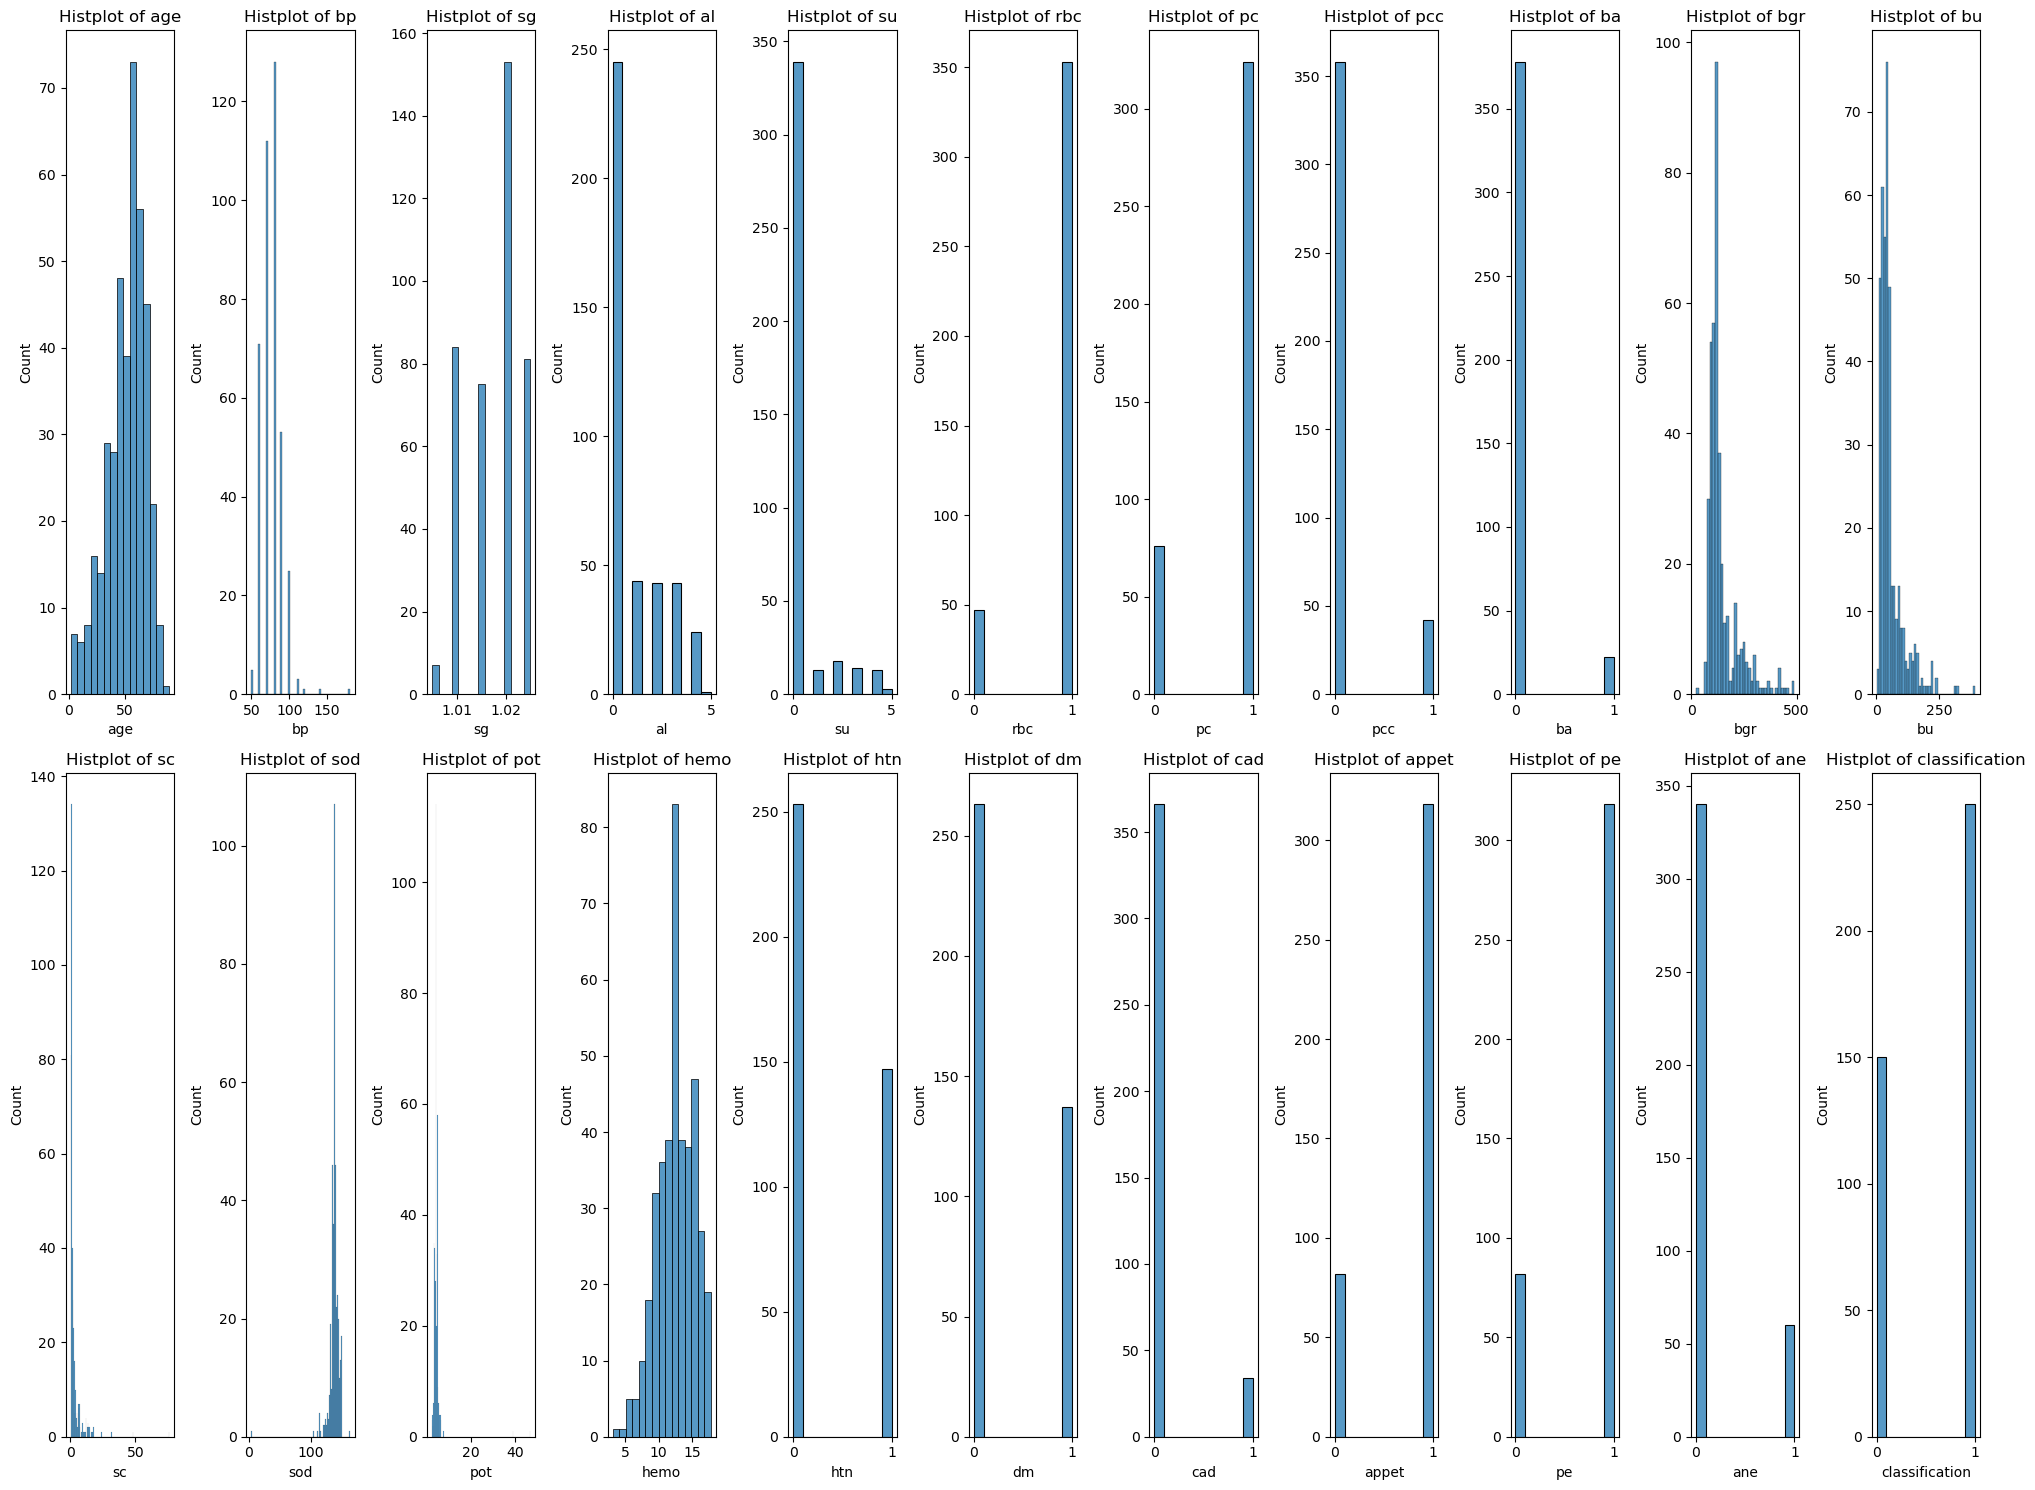

In [69]:
p = 1
for i in num:
    plt.subplot(2,11,p)
    sns.histplot(x = df[i])
    plt.title(f'Histplot of {i}')
    p+=1
plt.tight_layout()
plt.show()

**Inference:** Categorical variables are imbalanced, and clinical features like hemo show near-normal distribution, making them strong indicators for CKD prediction.

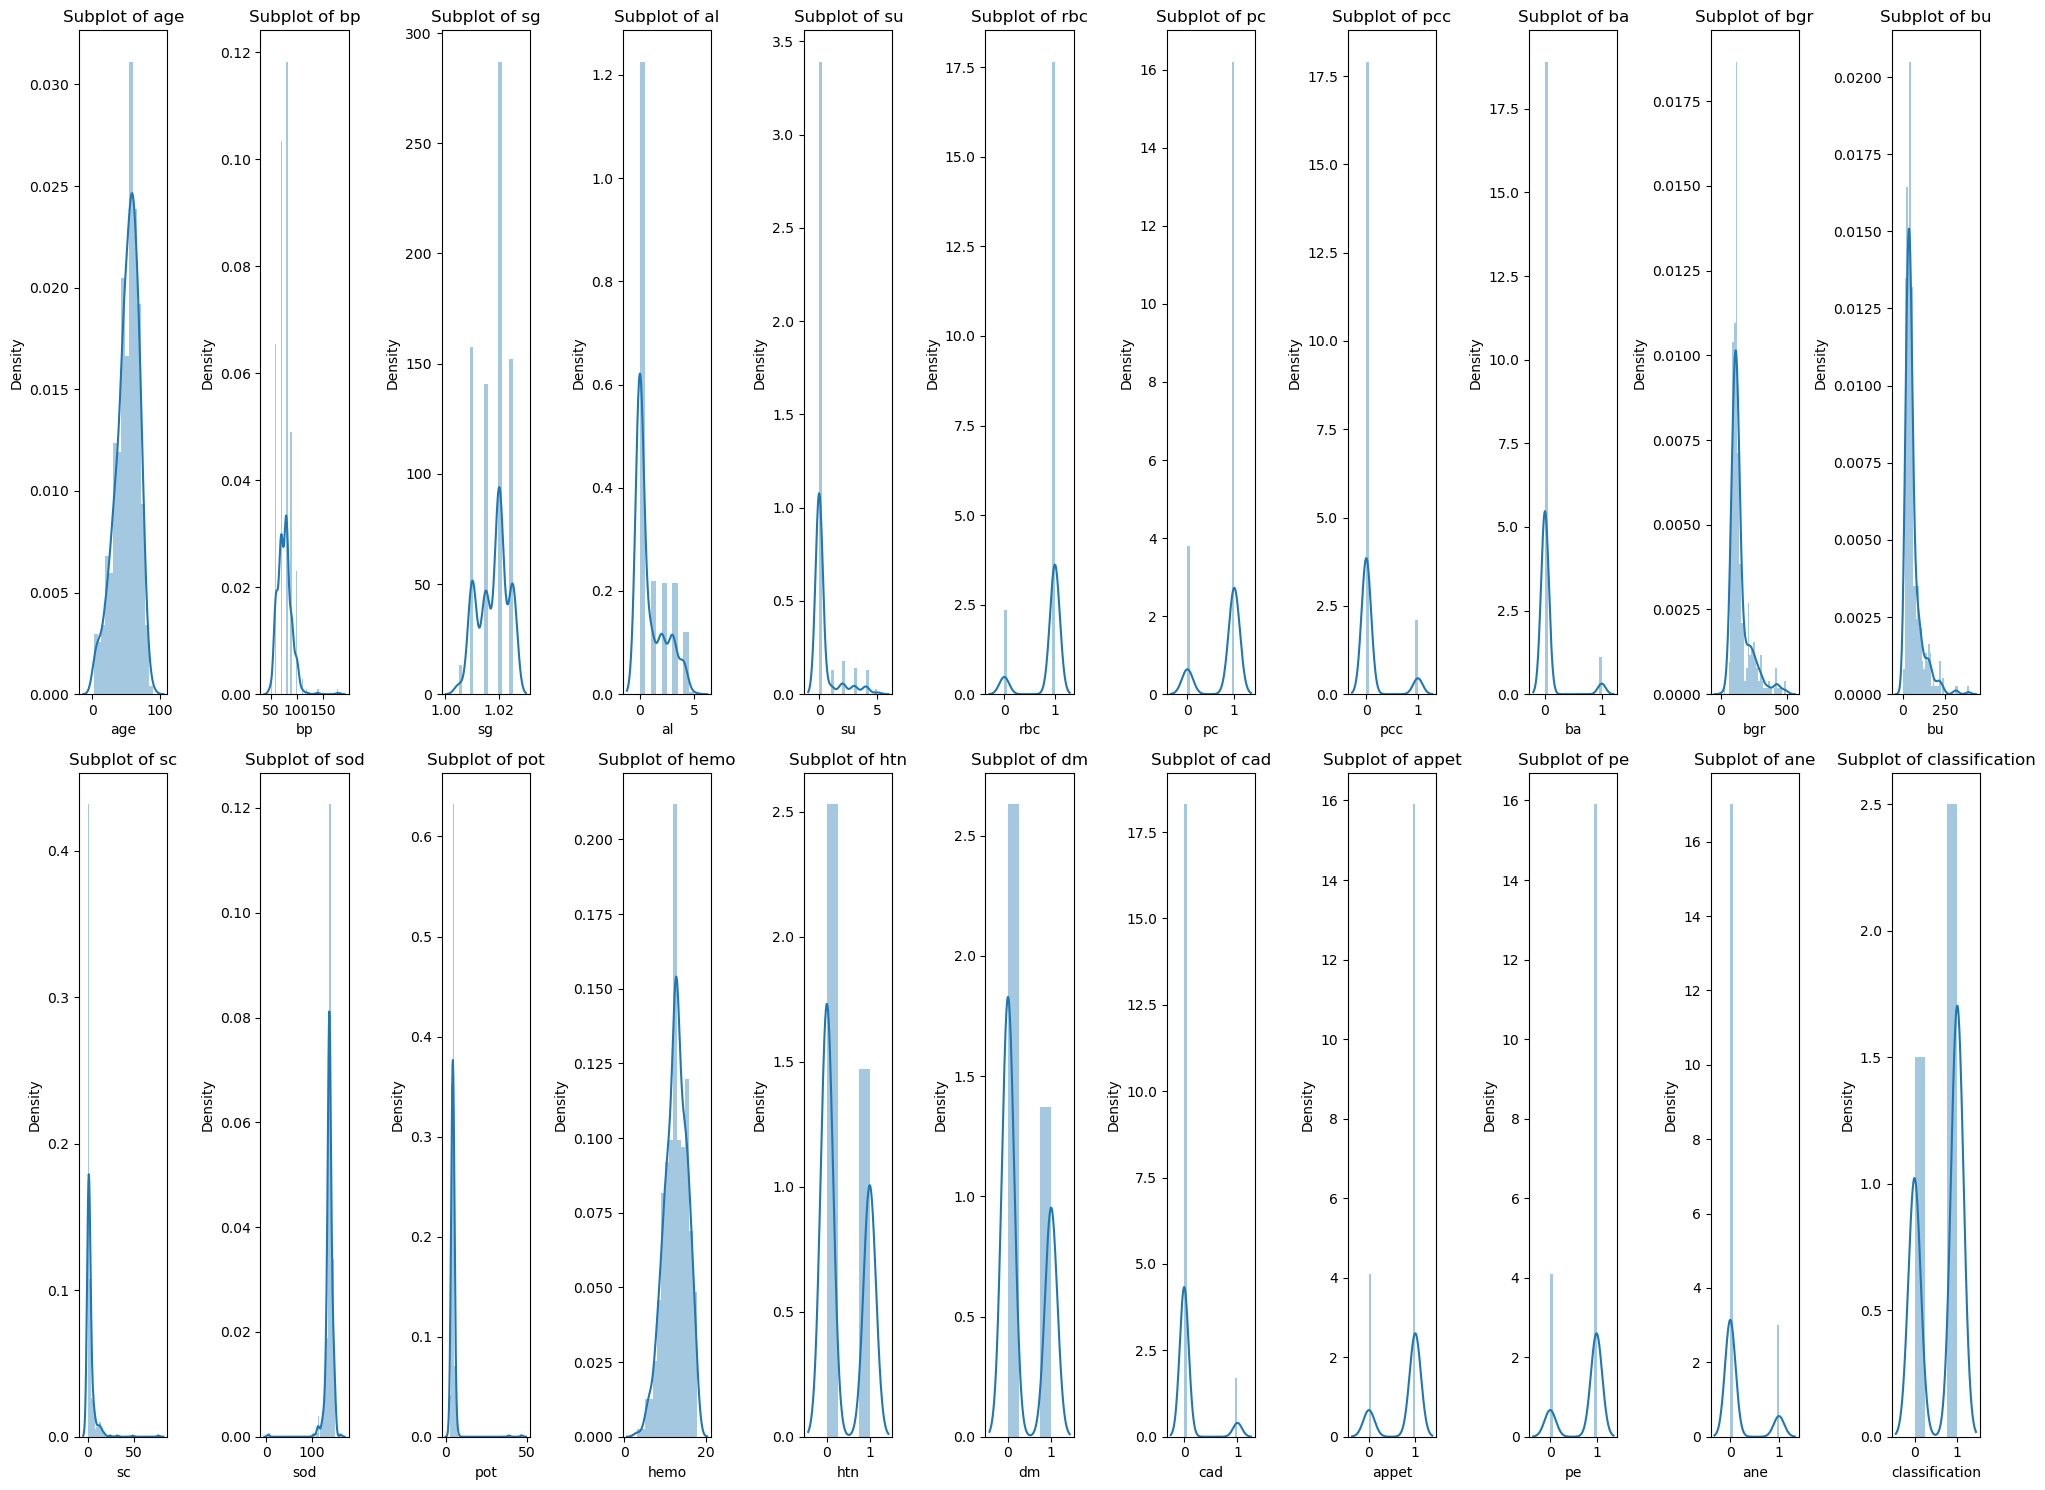

In [70]:
p = 1
for i in num:
    plt.subplot(2,11,p)
    sns.distplot(df[i])
    plt.title(f'Subplot of {i}')
    p +=1
plt.tight_layout()
plt.show()

**Inference:** Distplots show that most variables are not normally distributed, with clear skewness and uneven spread, indicating variability in patient health conditions.

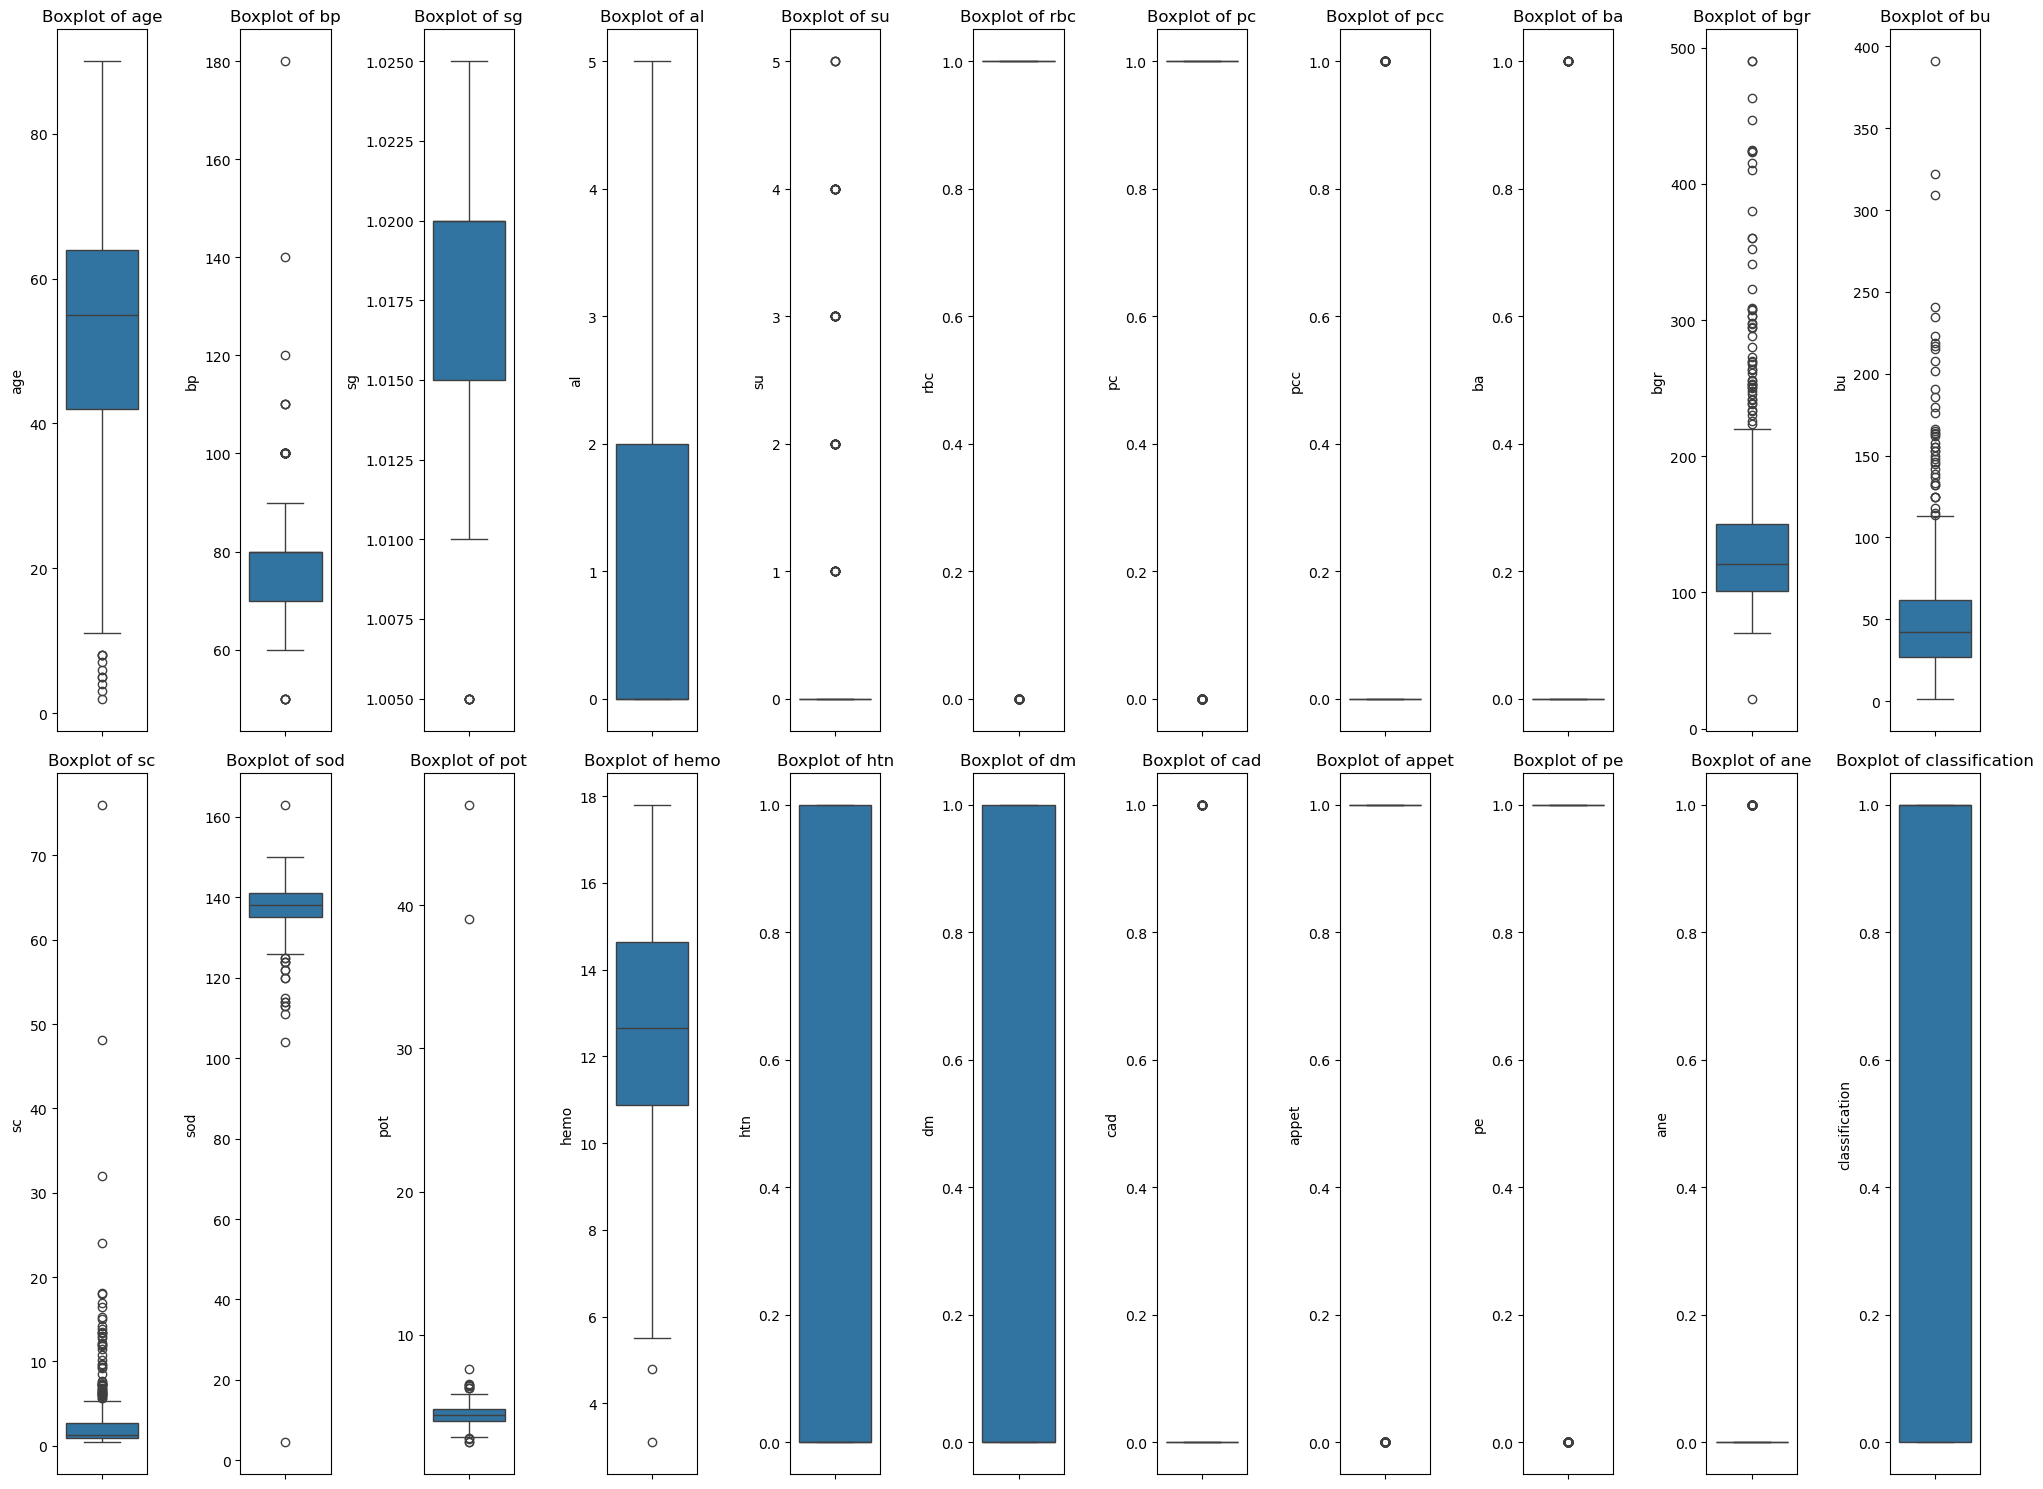

In [71]:
p = 1
for i in num:
    plt.subplot(2,11,p)
    sns.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    p+=1
plt.tight_layout()
plt.show()

**Inference:** The boxplots reveal significant outliers in key numerical features like bgr, bu, sc, sod, and pot, indicating abnormal medical readings in some patients.

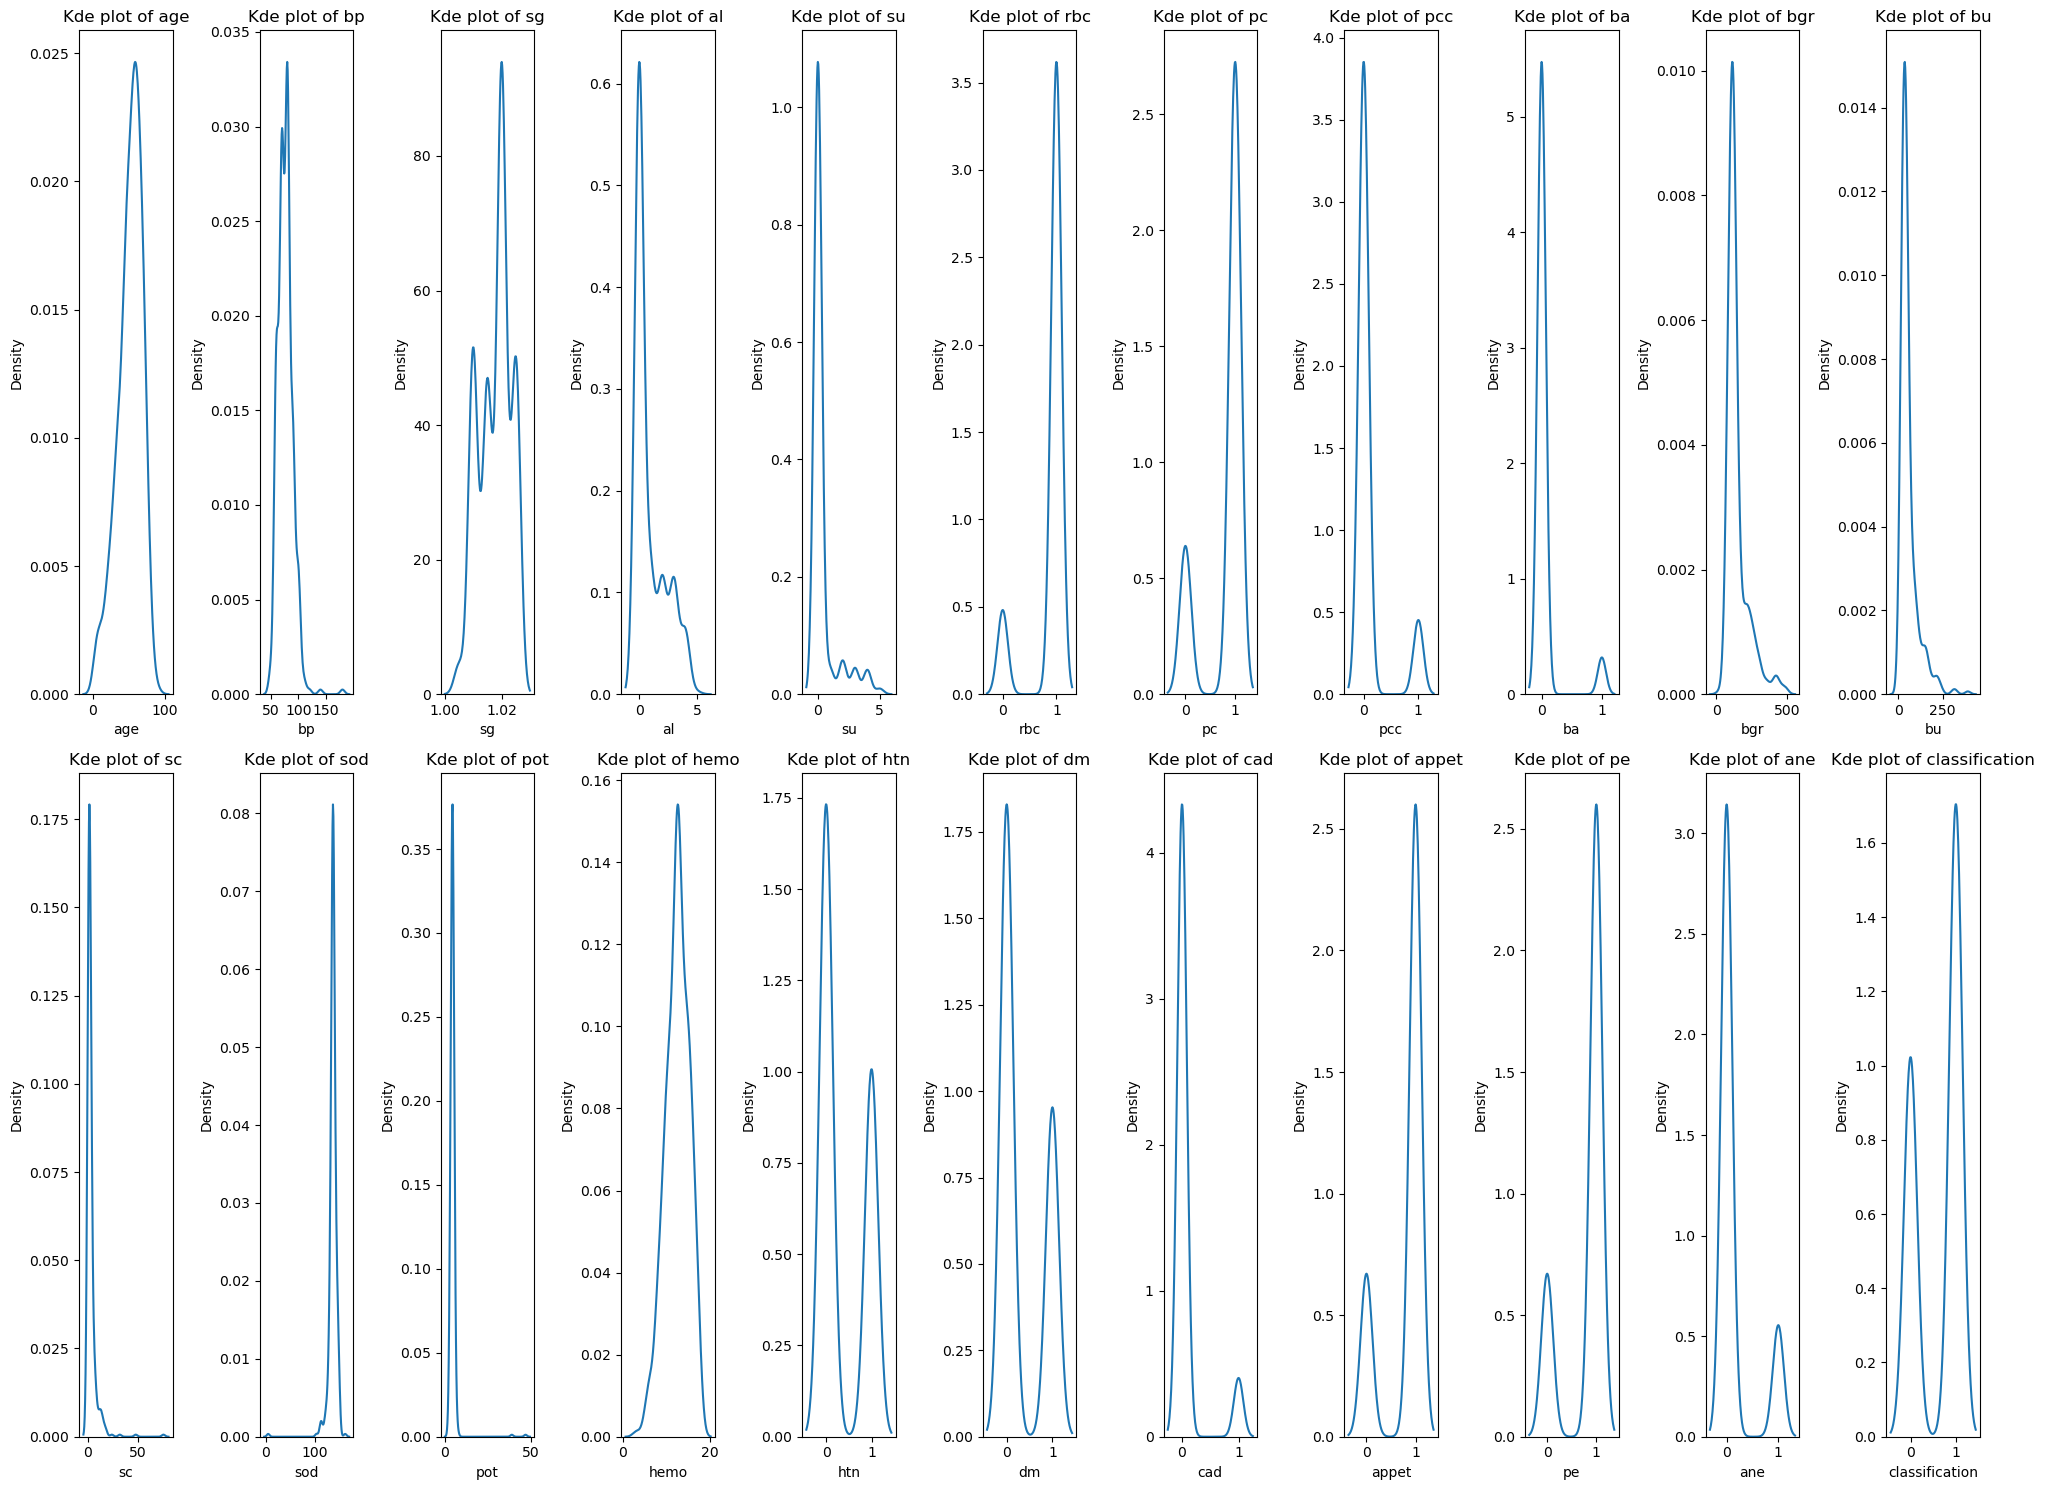

In [72]:
p = 1
for i in num:
    plt.subplot(2,11,p)
    sns.kdeplot(df[i])
    plt.title(f'Kde plot of {i}')
    p+=1
plt.tight_layout()
plt.show()

**Inference:** KDE plots indicate that most clinical features have peaked and uneven density shapes, showing that patient values are concentrated in specific ranges rather than being normally distributed.

In [73]:
len(cat)

3

In [74]:
 x=i,

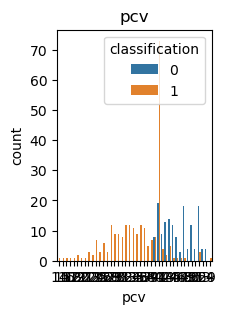

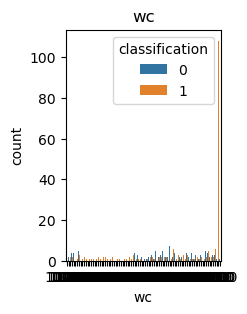

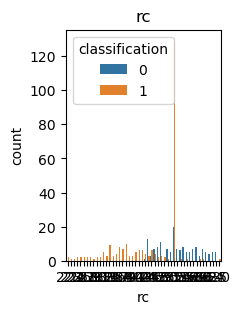

In [75]:
for i in cat:
    plt.figure(figsize=(2,3))
    sns.countplot(x=i, hue='classification', data=df,order=sorted(df[i].unique()))
    plt.title(i)
plt.show()

**Inference:** pcv, wc, and rc show noticeable class-wise differences, where CKD (1) tends to cluster at abnormal ranges while non-CKD (0) is more spread across normal values.

### Bivariate Analysis

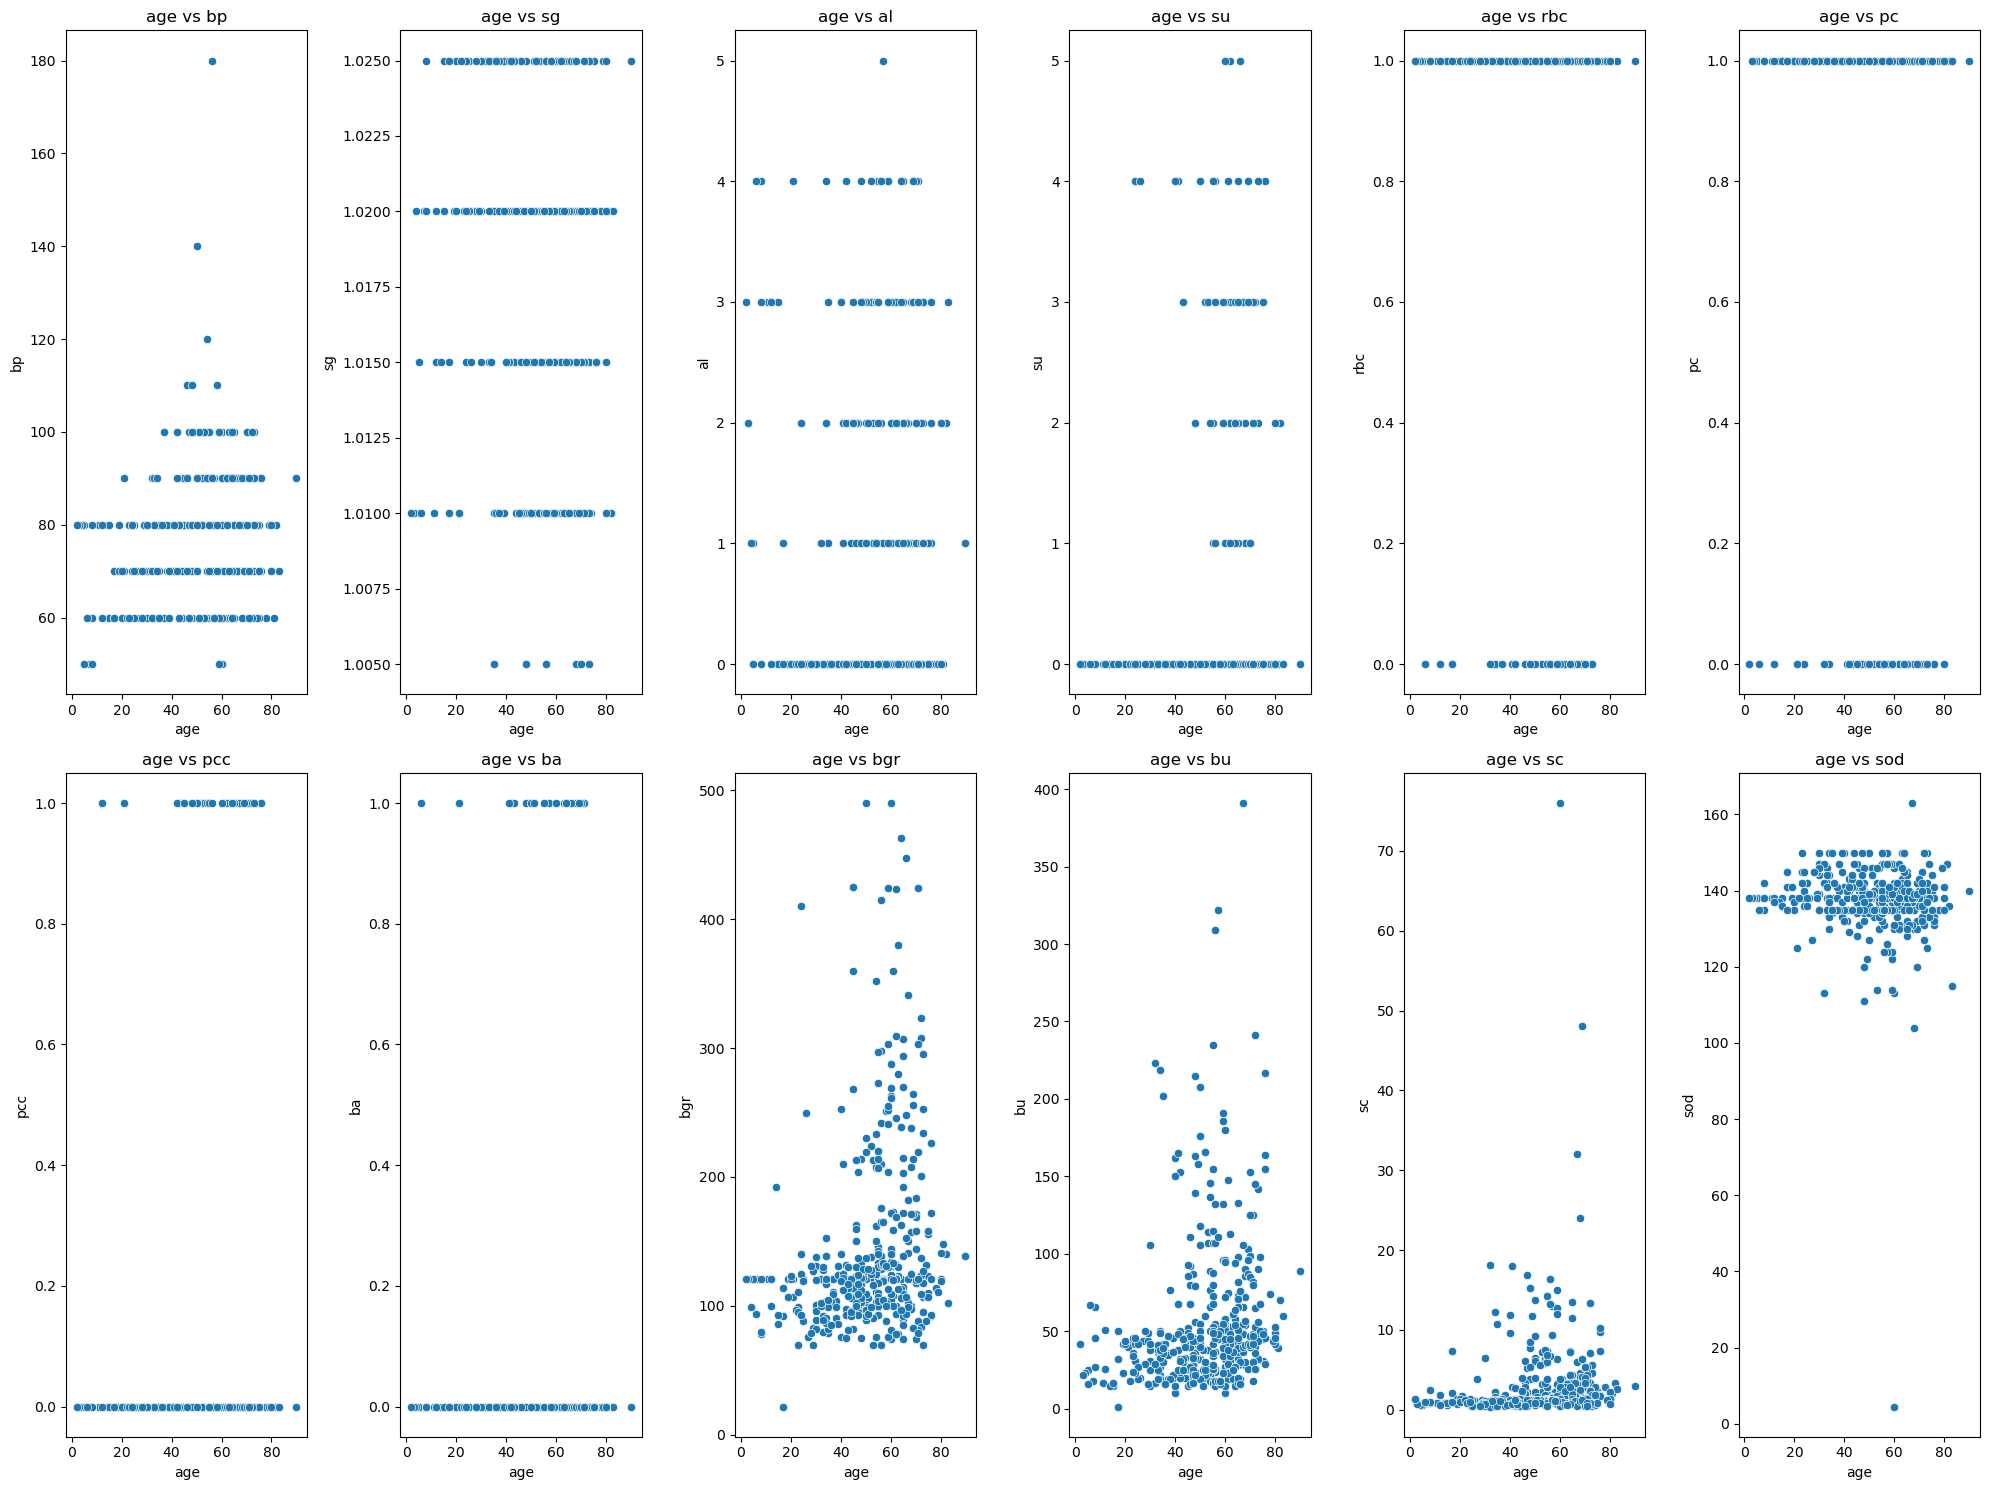

In [76]:
p = 1
for i in num:
    for j in num:
        if i != j and p <= 12:
            plt.subplot(2,6,p)
            sns.scatterplot(x=df[i], y=df[j])
            plt.title(f'{i} vs {j}')
            p += 1

plt.tight_layout()
plt.show()

**Inference:** Most variables (al, su, rbc, pc, pcc, ba) appear as discrete/binary levels across all ages, showing no strong relationship with age. However, variables like **bgr, bu, and sc show increasing spread and higher values with age**, suggesting that kidney-related parameters tend to worsen or vary more in older individuals, while **bp and sod remain relatively stable across age groups**.


## Converting categoric to numeric for further analysis

In [77]:
df['wc'] = df['wc'].astype(int)

In [78]:
df['pcv'] = df['pcv'].astype(int)

In [79]:
df['rc'] = df['rc'].astype(float)

In [80]:
df.dtypes

age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                 int64
wc                  int64
rc                float64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification      int64
dtype: object

## Multivariate Plots

In [81]:
plt.rcParams['figure.figsize'] = [30,29]

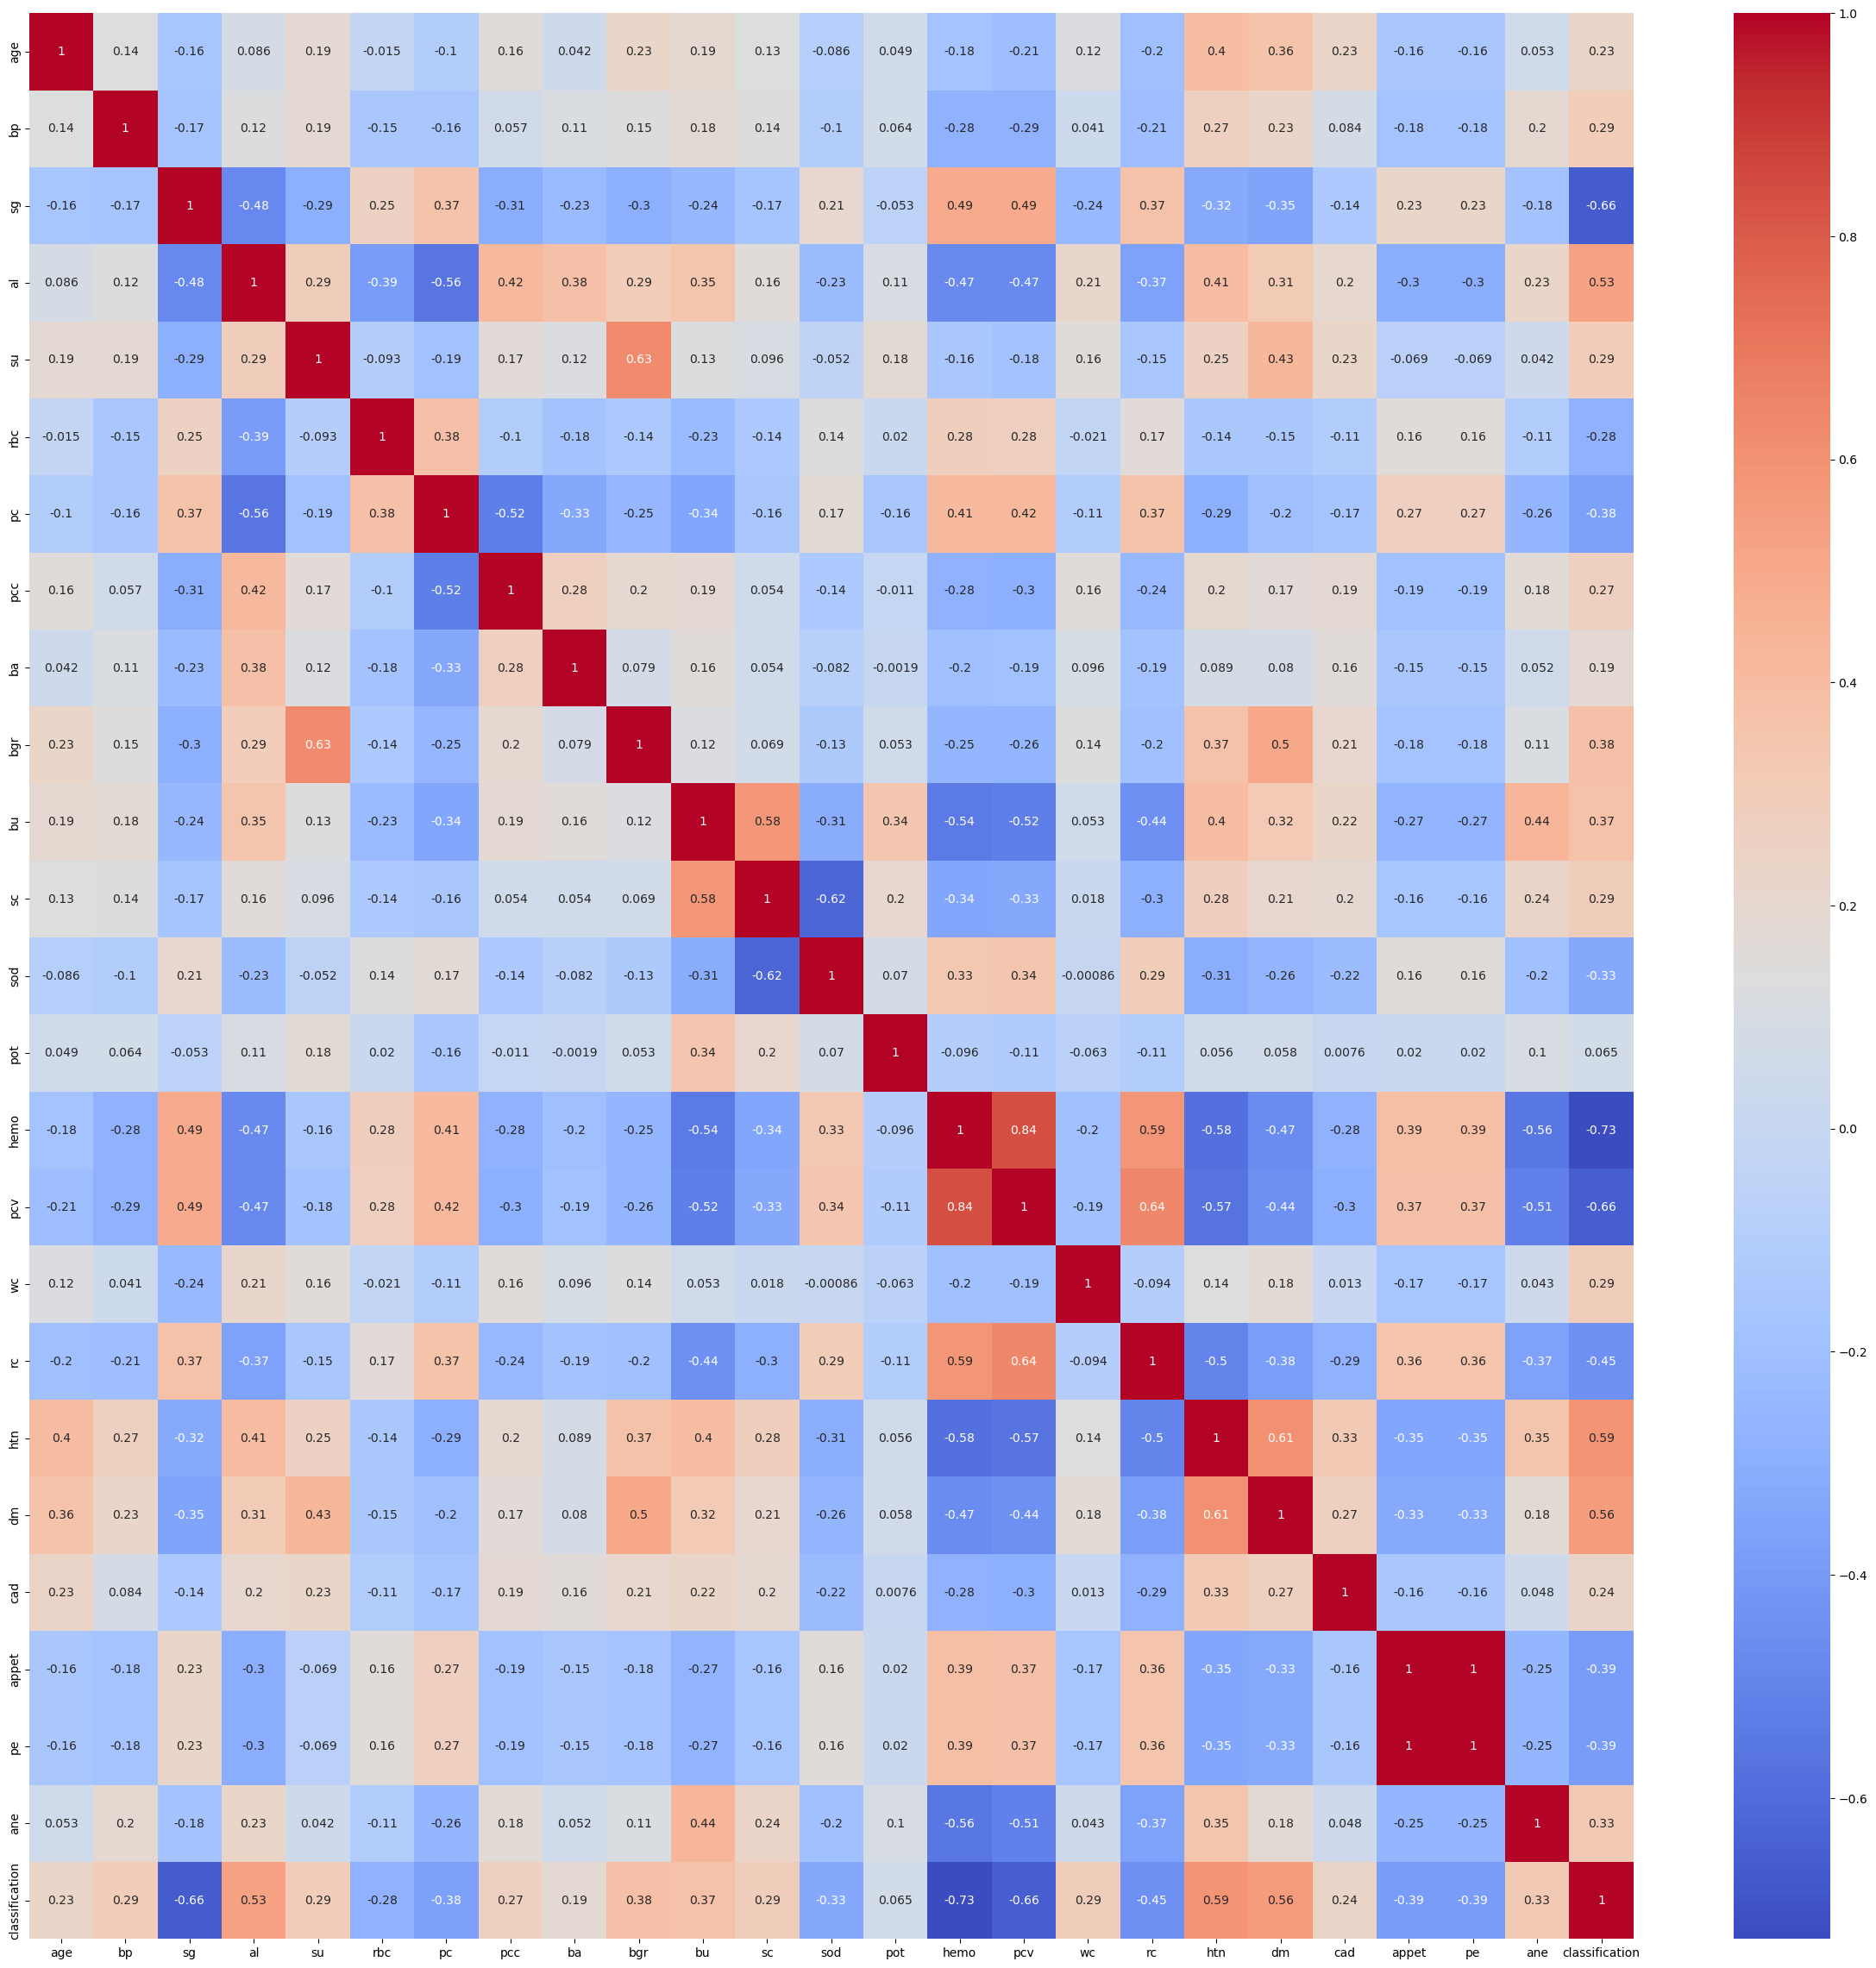

In [82]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Inference:** The correlation heatmap shows that pe and appet are highly correlated.

#### removing columns that are highly correlated

In [83]:
df = df.drop(['pe' , 'appet'] , axis = 1)

**Inference:** The categories columns are converted to numeric for futher analysis purposes.

## Transformation

In [84]:
df.skew()

age               -0.688736
bp                 1.601858
sg                -0.333320
al                 1.180088
su                 2.700055
rbc               -2.384616
pc                -1.586375
pcc                2.586749
ba                 3.918557
bgr                2.204143
bu                 2.724138
sc                 7.665610
sod               -7.929336
pot               13.132548
hemo              -0.376747
pcv               -0.606055
wc                 1.341390
rc                -0.704822
htn                0.551722
dm                 0.666294
cad                2.987387
ane                1.967779
classification    -0.518344
dtype: float64

In [85]:
from sklearn.preprocessing import PowerTransformer

In [86]:
p = PowerTransformer()

In [87]:
col = ['su' , 'pcc' , 'ba', 'bgr' , 'bu' , 'sc' , 'pot' , 'cad']

In [88]:
for i in col:
    df[i] = p.fit_transform(df[[i]])

In [89]:
df.skew()

age              -0.688736
bp                1.601858
sg               -0.333320
al                1.180088
su                1.941039
rbc              -2.384616
pc               -1.586375
pcc               2.586749
ba                3.918557
bgr              -0.197806
bu               -0.045031
sc                0.281972
sod              -7.929336
pot              -0.375716
hemo             -0.376747
pcv              -0.606055
wc                1.341390
rc               -0.704822
htn               0.551722
dm                0.666294
cad               2.987387
ane               1.967779
classification   -0.518344
dtype: float64

**Inference:** The skewness of the data is checked before and after the transformation and the conclusion is that some columns has reduced skewness after transformation and some columns did not reduce their skewness, for now the columns whose skewness is not reduced  will be kept for further analysis and will be checked later.

## Train Test Split

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
x = df.drop('classification' , axis = 1)
y = df['classification']

In [92]:
xtrain , xtest , ytrain , ytest = train_test_split(x , y , test_size = 0.3 , random_state = 42 , stratify = y)

## Model Building

In [93]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
model1 = RandomForestClassifier()
model1.fit(xtrain , ytrain)

RandomForestClassifier()

In [95]:
ypred1 = model1.predict(xtest)

In [96]:
from sklearn.metrics import confusion_matrix , classification_report

In [97]:
print(classification_report(ypred1,ytest))
print(confusion_matrix(ypred1,ytest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        75

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[45  0]
 [ 0 75]]


**Inference:** Accuracy is 1 and this indicates the model is overfitting so to overcome this I will perform variance inflation factor and check columns with multicollinearity and columns with high multicollinearity will be removed and this model will be performed again

In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [99]:
vif_data = pd.DataFrame()
vif_data['Features'] = xtrain.columns
vif_data['VIF values'] = [VIF(xtrain.values , i) for i in range(xtrain.shape[1])]

In [100]:
 vif_data.sort_values(by  = 'VIF values' , ascending = False)

,Features,VIF values
2,sg,421.218156
12,sod,239.491734
15,pcv,103.827493
14,hemo,97.397081
17,rc,65.188196
1,bp,37.089149
0,age,14.876755
16,wc,12.884791
5,rbc,12.599027
6,pc,10.960738


#### Removing column with high multicollinearity and checking the model again

In [101]:
xtrain_new1 = xtrain.drop(['sg'] , axis = 1)
xtest_new1 = xtest.drop(['sg'] , axis = 1)

In [102]:
model_new1 = RandomForestClassifier(random_state = 42)
model_new1.fit(xtrain_new1 , ytrain)

RandomForestClassifier(random_state=42)

In [103]:
ypred_new1 = model_new1.predict(xtest_new1)

In [104]:
print(classification_report(ypred_new1,ytest))
print(confusion_matrix(ypred_new1,ytest))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        46
           1       0.97      0.99      0.98        74

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120

[[44  2]
 [ 1 73]]


**Inference:** The Random Forest Classifier achieved an excellent accuracy of **97%**, indicating strong predictive performance in classifying CKD and

non-CKD patients. The model shows high precision, recall, and F1-scores for both classes, while the confusion matrix indicates very few 

misclassifications, proving the model is reliable and effective for kidney disease prediction.


## Decision Tree

In [105]:
from sklearn.tree import DecisionTreeClassifier

In [106]:
model2 = DecisionTreeClassifier()
model2.fit(xtrain_new1 , ytrain)

DecisionTreeClassifier()

In [107]:
ypred2 = model2.predict(xtest_new1)

In [108]:
print(classification_report(ypred2,ytest))
print(confusion_matrix(ypred2,ytest))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93        50
           1       0.92      0.99      0.95        70

    accuracy                           0.94       120
   macro avg       0.95      0.93      0.94       120
weighted avg       0.94      0.94      0.94       120

[[44  6]
 [ 1 69]]


**Inference:** The Decision Tree model achieved an accuracy of **94%**, showing good performance in predicting CKD and non-CKD cases. 

The model has high recall for class 1 (99%), meaning it correctly identifies most CKD patients, while the confusion matrix shows only a few 

misclassifications, indicating reliable classification performance.

## Gradient Boosting

In [109]:
from sklearn.ensemble import GradientBoostingClassifier

In [110]:
model3 = GradientBoostingClassifier(random_state=42)
model3.fit(xtrain_new1 , ytrain)

GradientBoostingClassifier(random_state=42)

In [111]:
ypred3 = model3.predict(xtest_new1)

In [112]:
print(classification_report(ypred2,ytest))
print(confusion_matrix(ypred2,ytest))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93        50
           1       0.92      0.99      0.95        70

    accuracy                           0.94       120
   macro avg       0.95      0.93      0.94       120
weighted avg       0.94      0.94      0.94       120

[[44  6]
 [ 1 69]]


**Inference:** The Gradient Boosting Classifier achieved an accuracy of **94%**, demonstrating strong performance in classifying CKD patients. 

The model shows high recall for class 1 (99%), indicating that it effectively identifies most kidney disease cases, while the confusion matrix 

reflects only a small number of prediction errors.

## Ada Boosting

In [113]:
from sklearn.ensemble import AdaBoostClassifier

In [114]:
model4 = AdaBoostClassifier(random_state = 42)
model4.fit(xtrain_new1 , ytrain)

AdaBoostClassifier(random_state=42)

In [115]:
ypred4 = model4.predict(xtest_new1)

In [116]:
print(classification_report(ypred4 , ytest))
print(confusion_matrix(ypred4 , ytest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        75

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[45  0]
 [ 0 75]]


**Inference:** The AdaBoost Classifier achieved 100% accuracy, with perfect precision, recall, and F1-scores for both classes. 

The confusion matrix shows zero misclassifications, indicating that the model classified all CKD and non-CKD patients correctly on the test dataset.

## Project Insights
* Most medical features showed skewed distributions and contained several outliers, especially blood glucose, blood urea, and serum creatinine.
* Strong positive correlations were observed between related kidney function indicators such as blood urea and serum creatinine.
* Features like hemoglobin and specific gravity showed negative correlation with CKD severity indicators.
* KDE plots and histograms revealed that many features are not normally distributed.
* Boxplots highlighted the presence of extreme values in important medical parameters.
* VIF analysis helped identify multicollinearity among features and assisted in feature selection.
* Scatterplots indicated that kidney-related abnormalities tend to increase with age in some patients.

## Conclusion
The project successfully analyzed and modeled the Chronic Kidney Disease dataset using data visualization and machine learning techniques. 

Important medical indicators such as blood glucose, serum creatinine, blood urea, and hemoglobin played a major role in CKD prediction.

After preprocessing and feature selection, the classification models were able to effectively distinguish CKD and non-CKD patients. 

This project demonstrates how machine learning can support early diagnosis and assist healthcare professionals in making better clinical decisions.